                  slice                 arm  n_train     mean      std
source-matched (flickr)    A (94k, scratch)      100 0.662400 0.014336
source-matched (flickr)    A (94k, scratch)      250 0.696033 0.031429
source-matched (flickr)    A (94k, scratch)      500 0.699300 0.024428
source-matched (flickr)    A (94k, scratch)     1000 0.727000 0.013256
source-matched (flickr)    A (94k, scratch)     1803 0.774233 0.015077
source-matched (flickr) B0 (4M, pretrained)      100 0.854900 0.065277
source-matched (flickr) B0 (4M, pretrained)      250 0.906367 0.019409
source-matched (flickr) B0 (4M, pretrained)      500 0.930067 0.007444
source-matched (flickr) B0 (4M, pretrained)     1000 0.934367 0.003287
source-matched (flickr) B0 (4M, pretrained)     1803 0.942400 0.002563
source-matched (flickr)    B0 (4M, scratch)      100 0.653167 0.038583
source-matched (flickr)    B0 (4M, scratch)      250 0.729467 0.007379
source-matched (flickr)    B0 (4M, scratch)      500 0.755667 0.014717
source

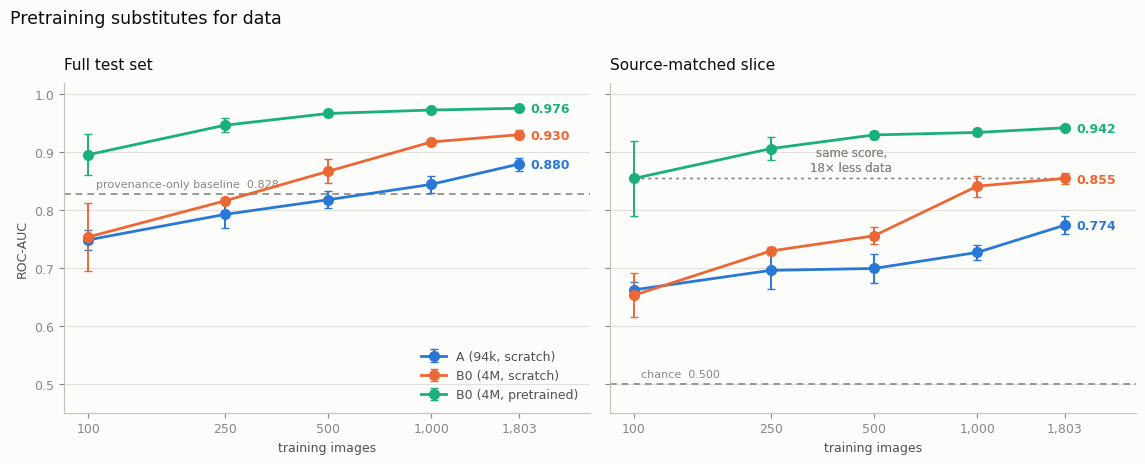

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

# --- palette (validated: adjacent CVD ΔE 9.2, normal-vision 27.6) ---
SERIES  = {'A (94k, scratch)': '#2a78d6',
           'B0 (4M, scratch)': '#eb6834',
           'B0 (4M, pretrained)': '#1baf7a'}
SURFACE, INK, INK2, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'

FULL_N = 1803

R  = '/kaggle/input/datasets/rayyanshuda/model-and-dataset-efficiency-results'
DE = M4 = M5 = R          # everything now lives in one place

COLS = ['arm', 'n_train', 'seed', 'slice', 'roc_auc', 'accuracy', 'specificity']

def curve_part(path, arm):
    d = pd.read_csv(path); d['arm'] = arm
    return d[COLS]

def full_part(path, prefix, arm):
    d = pd.read_csv(path)
    d = d[d.model.str.startswith(prefix)].copy()
    d['arm'], d['n_train'] = arm, FULL_N
    d['seed'] = d.model.str[-1].astype(int)
    return d[COLS]

A, S, P = 'A (94k, scratch)', 'B0 (4M, scratch)', 'B0 (4M, pretrained)'
df = pd.concat([
    curve_part(f'{DE}/dataeff_model_a.csv',        A),
    curve_part(f'{DE}/dataeff_b0_scratch.csv',     S),
    curve_part(f'{DE}/dataeff_b0_pretrained.csv',  P),
    full_part(f'{M4}/model_a_results.csv', 'model_a_seed',          A),
    full_part(f'{M5}/model_b_results.csv', 'model_b_scratch',       S),
    full_part(f'{M5}/model_b_results.csv', 'model_b_pretrained',    P),
], ignore_index=True)

agg = (df.groupby(['slice', 'arm', 'n_train'])['roc_auc']
         .agg(['mean', 'std']).reset_index())
print(agg[agg['slice'] == 'source-matched (flickr)'].to_string(index=False))   # verify vs the results doc

# --- figure ---
PANELS = [('full test', 'Full test set', 0.828, 'provenance-only baseline  0.828'),
          ('source-matched (flickr)', 'Source-matched slice', 0.500, 'chance  0.500')]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True, facecolor=SURFACE)

for ax, (sl, title, ref, ref_lab) in zip(axes, PANELS):
    ax.set_facecolor(SURFACE)
    ax.axhline(ref, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=1)
    ax.text(105, ref + 0.008, ref_lab, color=MUTED, fontsize=8, va='bottom')

    for arm, colour in SERIES.items():
        d = agg[(agg['slice'] == sl) & (agg.arm == arm)].sort_values('n_train')
        ax.errorbar(d.n_train, d['mean'], yerr=d['std'], color=colour, lw=2,
                    marker='o', ms=7, capsize=3, elinewidth=1.4,
                    label=arm, zorder=3)
        ax.annotate(f"{d['mean'].iloc[-1]:.3f}",                    # direct label
                    (d.n_train.iloc[-1], d['mean'].iloc[-1]),
                    textcoords='offset points', xytext=(8, -3),
                    color=colour, fontsize=9, fontweight='bold')

    ax.set_xscale('log')
    ax.set_xlim(85, 2900)
    ax.xaxis.set_major_locator(FixedLocator([100, 250, 500, 1000, 1803]))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.xaxis.set_minor_locator(FixedLocator([]))
    ax.set_title(title, fontsize=11, color=INK, pad=10, loc='left')
    ax.set_xlabel('training images', fontsize=9, color=INK2)
    ax.grid(axis='y', color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax = axes[1]
    ax.plot([100, 1803], [0.855, 0.855], color=MUTED, lw=1, ls=(0, (2, 3)), zorder=2)
    ax.annotate('same score,\n18× less data', xy=(430, 0.862),
            color=MUTED, fontsize=8.5, ha='center', va='bottom')

axes[0].set_ylabel('ROC-AUC', fontsize=9, color=INK2)
axes[0].set_ylim(0.45, 1.02)
axes[0].legend(frameon=False, fontsize=9, loc='lower right', labelcolor=INK2)

fig.suptitle('Pretraining substitutes for data', # the gap it closes depends on how much i have'
             fontsize=12.5, color=INK, x=0.008, ha='left', y=1.0)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_learning_curve.png', dpi=200,
            bbox_inches='tight', facecolor=SURFACE)
plt.show()

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

R = '/kaggle/input/datasets/rayyanshuda/model-and-dataset-efficiency-results'

# validated palette — adjacent CVD ΔE 9.2, normal-vision 27.6, all checks pass
SERIES = {'A (94k, scratch)':    '#2a78d6',
          'B0 (4M, scratch)':    '#eb6834',
          'B0 (4M, pretrained)': '#1baf7a'}
TRAIN_C, VAL_C = '#2a78d6', '#eb6834'

SURFACE = '#fcfcfb'    # chart surface
INK     = '#0b0b0b'    # primary text
INK2    = '#52514e'    # secondary text
MUTED   = '#898781'    # axis labels, reference lines
GRID    = '#e1e0d9'    # hairline gridlines
AXIS    = '#c3c2b7'    # baseline / spines

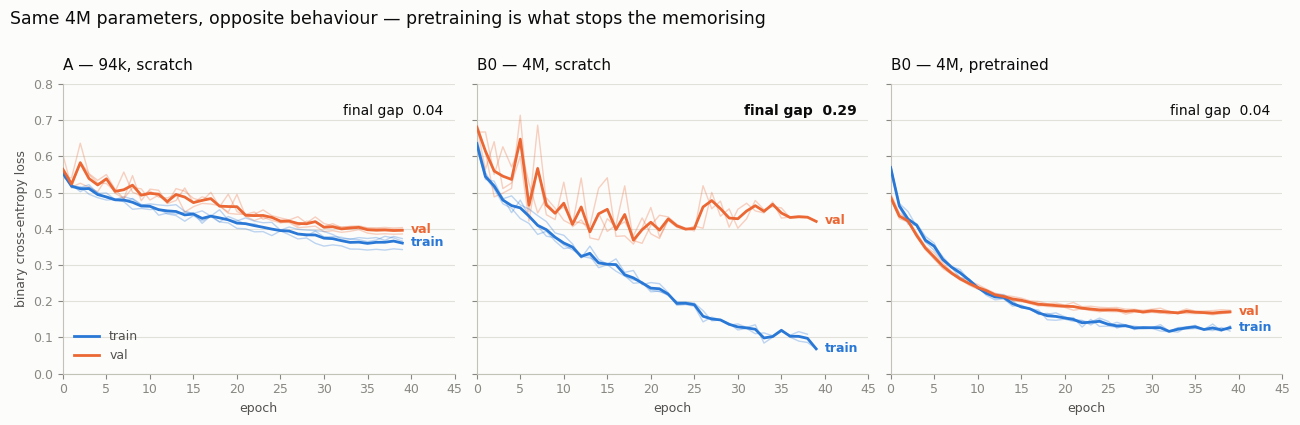

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

ARMS = [('model_a',            'A — 94k, scratch',      0.05),
        ('model_b_scratch',    'B0 — 4M, scratch',      None),
        ('model_b_pretrained', 'B0 — 4M, pretrained',   None)]

TRAIN_C, VAL_C = '#2a78d6', '#eb6834'

def load_hist(prefix):
    out = []
    for s in (0, 1, 2):
        d = pd.read_csv(f'{R}/{prefix}_seed{s}_history.csv')
        d['seed'] = s
        out.append(d)
    return pd.concat(out, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True, facecolor=SURFACE)

for ax, (prefix, title, _) in zip(axes, ARMS):
    h = load_hist(prefix)
    ax.set_facecolor(SURFACE)

    for seed, d in h.groupby('seed'):                      # individual seeds, faint
        d = d.sort_values('epoch')
        ax.plot(d.epoch, d.train_loss, color=TRAIN_C, lw=1, alpha=0.30, zorder=2)
        ax.plot(d.epoch, d.val_loss,   color=VAL_C,   lw=1, alpha=0.30, zorder=2)

    m = h.groupby('epoch')[['train_loss', 'val_loss']].mean().reset_index()
    ax.plot(m.epoch, m.train_loss, color=TRAIN_C, lw=2, label='train', zorder=3)
    ax.plot(m.epoch, m.val_loss,   color=VAL_C,   lw=2, label='val',   zorder=3)

    # final gap, averaged over each seed's own last epoch
    last = h.sort_values('epoch').groupby('seed').tail(1)
    gap  = (last.val_loss - last.train_loss).mean()
    ax.annotate(f'final gap  {gap:.2f}', xy=(0.97, 0.93), xycoords='axes fraction',
                ha='right', va='top', fontsize=10, color=INK,
                fontweight='bold' if gap > 0.2 else 'normal')

    ax.annotate('train', (m.epoch.iloc[-1], m.train_loss.iloc[-1]),
                textcoords='offset points', xytext=(6, -2),
                color=TRAIN_C, fontsize=9, fontweight='bold')
    ax.annotate('val', (m.epoch.iloc[-1], m.val_loss.iloc[-1]),
                textcoords='offset points', xytext=(6, -2),
                color=VAL_C, fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=11, color=INK, pad=10, loc='left')
    ax.set_xlabel('epoch', fontsize=9, color=INK2)
    ax.set_xlim(0, 45)
    ax.grid(axis='y', color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9)

axes[0].set_ylabel('binary cross-entropy loss', fontsize=9, color=INK2)
axes[0].set_ylim(0, 0.80)
axes[0].legend(frameon=False, fontsize=9, loc='lower left', labelcolor=INK2)

fig.suptitle('Same 4M parameters, opposite behaviour — pretraining is what stops the memorising',
             fontsize=12.5, color=INK, x=0.008, ha='left', y=1.0)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_overfitting.png', dpi=200,
            bbox_inches='tight', facecolor=SURFACE)
plt.show()

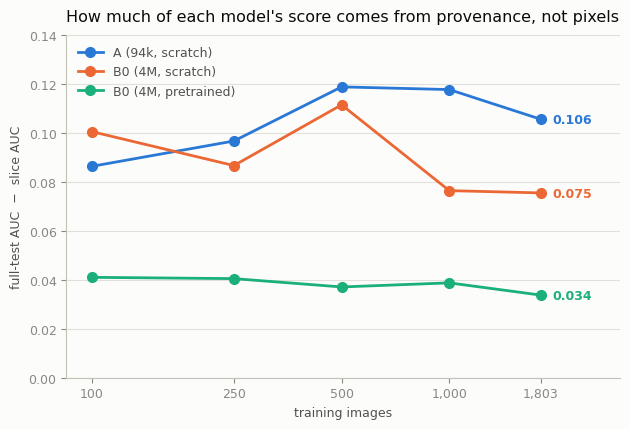

In [4]:
piv = agg.pivot_table(index=['arm', 'n_train'], columns='slice', values='mean').reset_index()
piv['reliance'] = piv['full test'] - piv['source-matched (flickr)']

fig, ax = plt.subplots(figsize=(6.4, 4.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for arm, colour in SERIES.items():
    d = piv[piv.arm == arm].sort_values('n_train')
    ax.plot(d.n_train, d.reliance, color=colour, lw=2, marker='o', ms=7, label=arm)
    ax.annotate(f"{d.reliance.iloc[-1]:.3f}", (d.n_train.iloc[-1], d.reliance.iloc[-1]),
                textcoords='offset points', xytext=(8, -3),
                color=colour, fontsize=9, fontweight='bold')

ax.set_xscale('log'); ax.set_xlim(85, 3000); ax.set_ylim(0, 0.14)
ax.xaxis.set_major_locator(FixedLocator([100, 250, 500, 1000, 1803]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.xaxis.set_minor_locator(FixedLocator([]))
ax.set_xlabel('training images', fontsize=9, color=INK2)
ax.set_ylabel('full-test AUC  −  slice AUC', fontsize=9, color=INK2)
ax.set_title('How much of each model\'s score comes from provenance, not pixels',
             fontsize=11.5, color=INK, loc='left', pad=10)
ax.grid(axis='y', color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
for s in ('left', 'bottom'): ax.spines[s].set_color(AXIS)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, fontsize=9, loc='upper left', labelcolor=INK2)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_shortcut_reliance.png', dpi=200,
            bbox_inches='tight', facecolor=SURFACE)
plt.show()